In [1]:
import sys
sys.path.insert(0, "../include")
from gc_utils import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Generate synthetic data
L = 100
rho = 1/0.67
vN = 7.7; 
vJ = 18.8; 
K = np.sqrt(vJ/vN); 
v = np.sqrt(vN*vJ); 
print(K,v)
A = 1
T= 0.5
mu = 0.0
x_vals = np.linspace(1, L/2, 1000)
corr_c_osc = canonical_paircorr(x_vals,K,v,A,L,T,1,rho)
corr_gc_osc = grandcanonical_paircorr(x_vals,K,v,A,L,T,1,rho,mu)

1.5625487005397436 12.031624994156028


In [3]:
#Now let us fit
canonical_fit_func = lambda x, K, v: canonical_envelope(x,K,v,A, L,T,rho,1)
grandcanonical_fit_func = lambda x, K, v: grandcanonical_envelope(x,K,v,A, L,T,rho,1,mu)
can_vals = fitpeaks(x_vals,corr_gc_osc,canonical_fit_func,prominence_frac=0.005,skip=20)
grandcan_vals = fitpeaks(x_vals,corr_gc_osc,grandcanonical_fit_func,prominence_frac=0.005,skip=5)

In [4]:
yabs = np.abs(corr_gc_osc)
prominence = 0.005* np.max(yabs)
peaks, properties = find_peaks(yabs, prominence=prominence)
xdata = x_vals
x_peaks = xdata[peaks][10:]
y_peaks_plot = corr_gc_osc[peaks][10:]

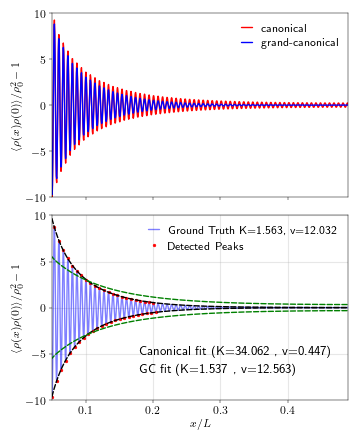

In [5]:
with plt.style.context('../include/aps.mplstyle'):
    figsize = plt.rcParams['figure.figsize']
    fig, ax = plt.subplots(2,1,constrained_layout=True, figsize=(figsize[0],2*figsize[1]),sharex=True)
    ax[0].plot(x_vals/L,corr_c_osc,'r-',label='canonical')
    ax[0].plot(x_vals/L,corr_gc_osc,'b-',label='grand-canonical')
    #ax[0].set_xlabel(r'$x/L$')
    ax[0].set_ylabel(r'$\langle \rho(x)\rho(0)\rangle/\rho_0^2 - 1$')
    ax[1].set_ylabel(r'$\langle \rho(x)\rho(0)\rangle/\rho_0^2 - 1$')
    ax[0].set_ylim(-10,10)
    ax[0].set_xlim(0.05,0.49)
    ax[1].plot(xdata/L, corr_gc_osc, 'b-', alpha=0.5, linewidth=1, label=f'Ground Truth K={K:.3f}, v={v:.3f}')
    ax[1].plot(x_peaks/L, y_peaks_plot, 'ro', label='Detected Peaks')
    ax[1].plot(xdata/L, grandcanonical_fit_func(xdata, grandcan_vals[0],grandcan_vals[2]), 'k--')
    ax[1].plot(xdata/L, -grandcanonical_fit_func(xdata, grandcan_vals[0],grandcan_vals[2]), 'k--')
    ax[1].plot(xdata/L, canonical_fit_func(xdata, can_vals[0],can_vals[2]), 'g--')
    ax[1].plot(xdata/L, -canonical_fit_func(xdata,can_vals[0],can_vals[2]), 'g--')
    ax[1].set_xlabel(r'$x/L$')
    ax[1].text(0.18,-5, rf'Canonical fit (K={can_vals[0]:.3f} , v={can_vals[2]:.3f})')
    ax[1].text(0.18,-7, rf'GC fit (K={grandcan_vals[0]:.3f}  , v={grandcan_vals[2]:.3f})')
    #ax.set_title('Oscillatory Data with Fitted Envelope')
    ax[1].legend(loc=1)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_ylim(-10,10)
    ax[1].set_xlim(0.05,0.49)
    ax[0].legend()
    ax[1].legend()
    #plt.show()
    plt.savefig('../figures/synthetic_data_and_fit.pdf')